In [1]:
# basic imports, adding more as I go if I need them
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# checking shapes first to understand the data
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3018s 18us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [3]:
# these are the 10 classes in cifar10 (got this from the dataset docs)
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# just printing number of training and testing images like manual asked
print("Training Images:", x_train.shape[0])
print("Testing Images:", x_test.shape[0])
print("Image Size:", x_train.shape[1], "x", x_train.shape[2], "x", x_train.shape[3])
print("Number of Classes:", len(class_names))


Training Images: 50000
Testing Images: 10000
Image Size: 32 x 32 x 3
Number of Classes: 10


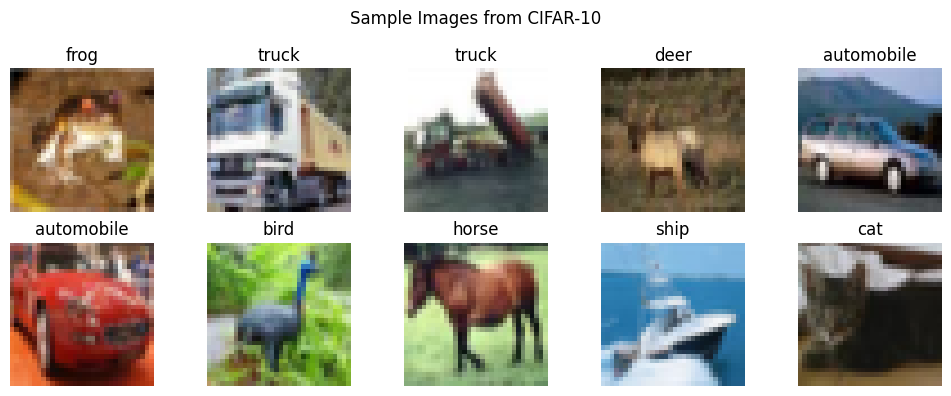

In [4]:
# showing 10 sample images
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10")
plt.tight_layout()
plt.show()


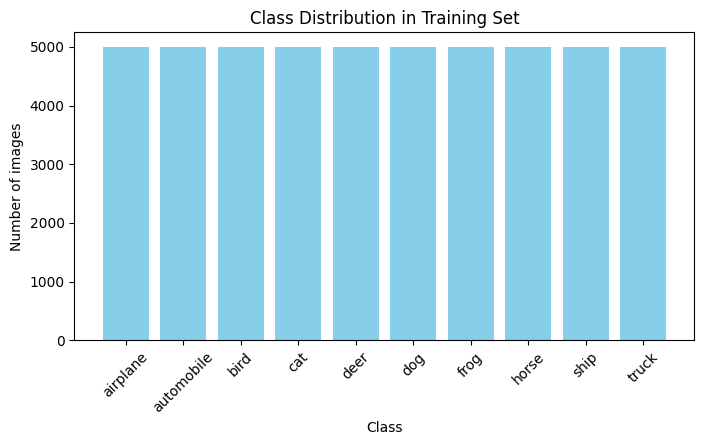

In [5]:
# plotting class distribution to see if dataset is balanced
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,4))
plt.bar([class_names[i] for i in unique], counts, color='skyblue')
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Class Distribution in Training Set")
plt.show()


In [6]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# also one hot encoding the labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(x_train_norm.shape, y_train_cat.shape)


(50000, 32, 32, 3) (50000, 10)


In [7]:
# taking just one image to test the conv layer output shapes
sample_img = x_train_norm[0:1]  # keeping batch dimension

for k in [3,5,7]:
    conv_layer = layers.Conv2D(filters=8, kernel_size=k, activation='relu', input_shape=(32,32,3))
    out = conv_layer(sample_img)
    print(f"Kernel size {k}x{k} -> Feature map shape: {out.shape}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Kernel size 3x3 -> Feature map shape: (1, 30, 30, 8)
Kernel size 5x5 -> Feature map shape: (1, 28, 28, 8)
Kernel size 7x7 -> Feature map shape: (1, 26, 26, 8)


In [8]:
print("--- Stride comparison (kernel=3, padding=valid) ---")
for s in [1,2]:
    conv_layer = layers.Conv2D(8, kernel_size=3, strides=s, padding='valid', activation='relu')
    out = conv_layer(sample_img)
    print(f"Stride {s} -> {out.shape}")

print()
print("--- Padding comparison (kernel=3, stride=1) ---")
for p in ['same','valid']:
    conv_layer = layers.Conv2D(8, kernel_size=3, strides=1, padding=p, activation='relu')
    out = conv_layer(sample_img)
    print(f"Padding {p} -> {out.shape}")


--- Stride comparison (kernel=3, padding=valid) ---
Stride 1 -> (1, 30, 30, 8)
Stride 2 -> (1, 15, 15, 8)

--- Padding comparison (kernel=3, stride=1) ---
Padding same -> (1, 32, 32, 8)
Padding valid -> (1, 30, 30, 8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
feature maps shape: (1, 32, 32, 16)


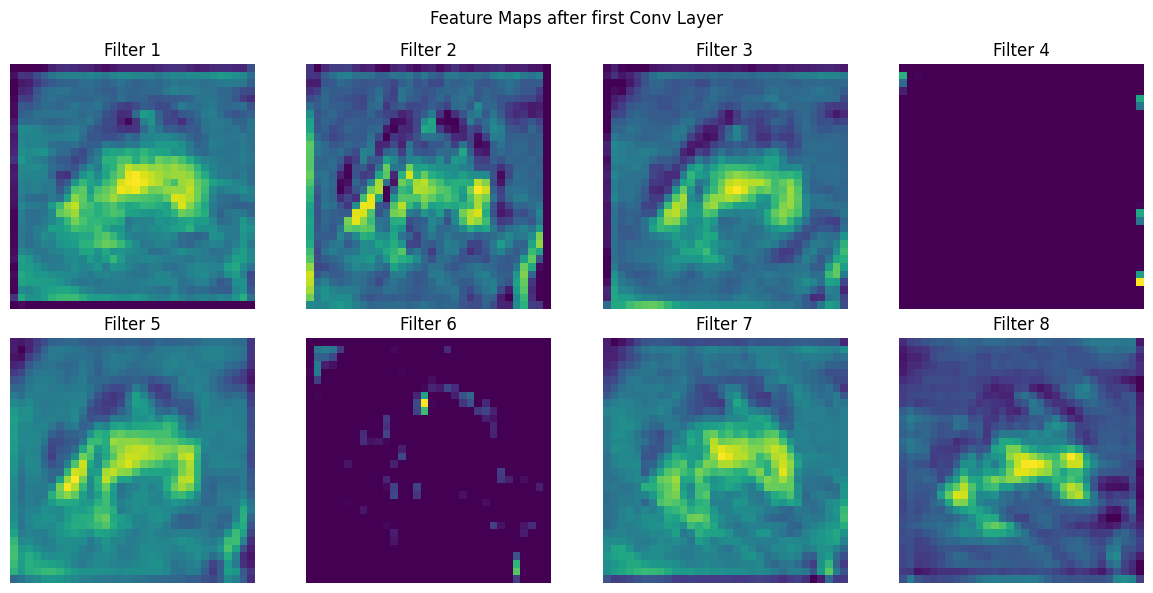

In [9]:
# small model just to visualize feature maps after first conv layer
feature_model = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(32,32,3))
])

feature_maps = feature_model.predict(sample_img)
print("feature maps shape:", feature_maps.shape)

# plotting first 8 feature maps
plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.suptitle("Feature Maps after first Conv Layer")
plt.tight_layout()
plt.show()


Input feature map shape: (1, 32, 32, 16)
After Max Pooling: (1, 16, 16, 16)
After Avg Pooling: (1, 16, 16, 16)


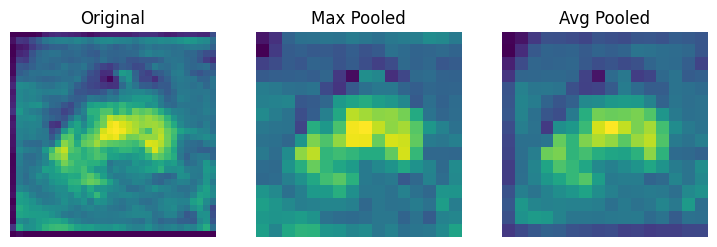

In [10]:
maxpool_layer = layers.MaxPooling2D((2,2))
avgpool_layer = layers.AveragePooling2D((2,2))

max_out = maxpool_layer(feature_maps)
avg_out = avgpool_layer(feature_maps)

print("Input feature map shape:", feature_maps.shape)
print("After Max Pooling:", max_out.shape)
print("After Avg Pooling:", avg_out.shape)

# visual comparison for one filter
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(feature_maps[0,:,:,0], cmap='viridis')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(max_out[0,:,:,0], cmap='viridis')
plt.title("Max Pooled")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(avg_out[0,:,:,0], cmap='viridis')
plt.title("Avg Pooled")
plt.axis('off')
plt.show()


In [11]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# note: 20 epochs takes a while on cpu, reduce if it takes too long
history = model.fit(x_train_norm, y_train_cat,
                     epochs=20,
                     batch_size=32,
                     validation_split=0.1)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4775 - loss: 1.4615 - val_accuracy: 0.5904 - val_loss: 1.1698
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6190 - loss: 1.0908 - val_accuracy: 0.6376 - val_loss: 1.0297
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6696 - loss: 0.9453 - val_accuracy: 0.6764 - val_loss: 0.9305
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7043 - loss: 0.8533 - val_accuracy: 0.6942 - val_loss: 0.8945
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7282 - loss: 0.7831 - val_accuracy: 0.6976 - val_loss: 0.8852
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7479 - loss: 0.7265 - val_accuracy: 0.7076 - val_loss: 0.8718
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7627 - loss: 0.6730 - val_accuracy: 0.6838 - val_loss: 0.9542
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7818 - loss: 0.6279 

## Training and Validation Plots

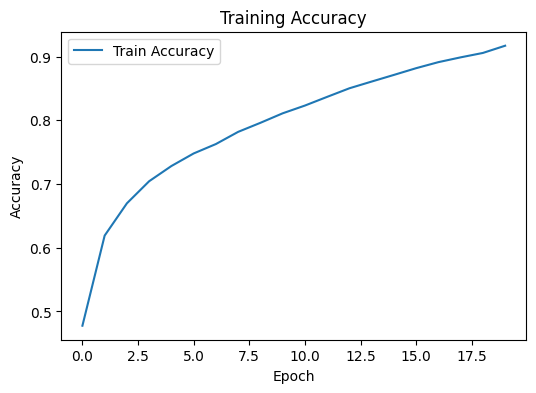

In [13]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()


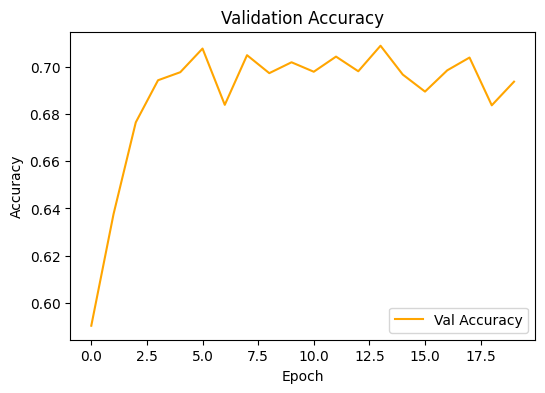

In [14]:
plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()


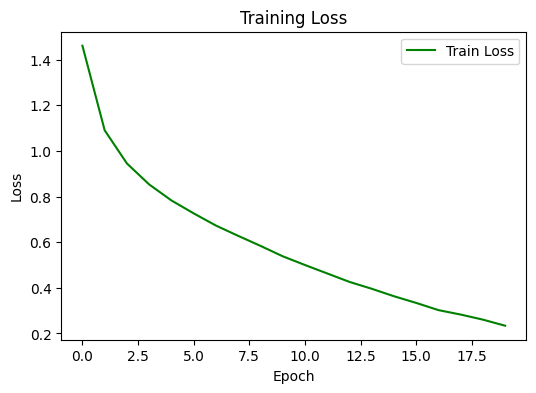

In [15]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()


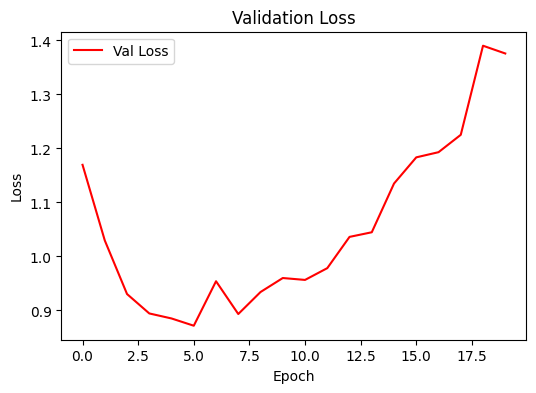

In [16]:
plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.show()


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# get predictions on test set
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Test Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Test Accuracy: 0.6799
Precision: 0.6890512968355254
Recall: 0.6799000000000001
F1-score: 0.6833777002648425


In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

    airplane       0.69      0.72      0.71      1000
  automobile       0.81      0.77      0.79      1000
        bird       0.53      0.62      0.57      1000
         cat       0.47      0.53      0.50      1000
        deer       0.66      0.62      0.64      1000
         dog       0.56      0.60      0.58      1000
        frog       0.78      0.73      0.75      1000
       horse       0.76      0.71      0.73      1000
        ship       0.84      0.75      0.79      1000
       truck       0.79      0.76      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



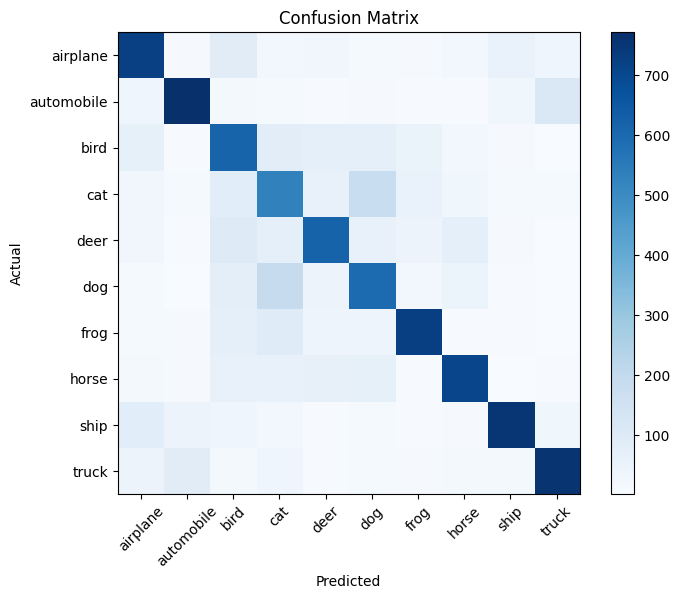

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [20]:
# double checking with code
N, F, P, S = 64, 5, 2, 2
output = (N - F + 2*P)//S + 1
print("Output size:", output)


Output size: 32


In [21]:
F, C, K = 3, 3, 64
params = (F*F*C + 1) * K
print("Trainable parameters:", params)


Trainable parameters: 1792


In [22]:
model_avgpool = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.AveragePooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.AveragePooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_avgpool.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# training for fewer epochs here just to compare quickly
history_avg = model_avgpool.fit(x_train_norm, y_train_cat, epochs=5, batch_size=32, validation_split=0.1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4130 - loss: 1.6221 - val_accuracy: 0.5314 - val_loss: 1.3304
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5556 - loss: 1.2413 - val_accuracy: 0.5890 - val_loss: 1.1637
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6142 - loss: 1.0936 - val_accuracy: 0.6190 - val_loss: 1.0749
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6445 - loss: 1.0056 - val_accuracy: 0.6422 - val_loss: 1.0128
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6692 - loss: 0.9398 - val_accuracy: 0.6742 - val_loss: 0.9514


In [23]:
import time

# quick test with 16 filters
start = time.time()
model16 = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model16.fit(x_train_norm, y_train_cat, epochs=3, batch_size=32, validation_split=0.1, verbose=0)
time16 = time.time() - start
acc16 = model16.evaluate(x_test_norm, y_test_cat, verbose=0)[1]

# quick test with 64 filters
start = time.time()
model64 = keras.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])
model64.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model64.fit(x_train_norm, y_train_cat, epochs=3, batch_size=32, validation_split=0.1, verbose=0)
time64 = time.time() - start
acc64 = model64.evaluate(x_test_norm, y_test_cat, verbose=0)[1]

print(f"16 filters -> accuracy: {acc16:.4f}, time: {time16:.2f}s")
print(f"64 filters -> accuracy: {acc64:.4f}, time: {time64:.2f}s")


16 filters -> accuracy: 0.5672, time: 17.29s
64 filters -> accuracy: 0.6099, time: 18.90s
